## Notes:
- Ran on a m8gn.16xlarge
- Processing took about 12 minutes

In [ ]:
%load_ext autoreload
%autoreload 2
import logging
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import frisky
import icechunk
import matplotlib.pyplot as plt
import zarr
from dask.distributed import Client
from dask_array.xarray import register

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid
from srm.plotting import locations, plot_cdf_by_location
from srm.utils import open_icechunk

register()
zarr.config.set({"async.concurrency": 128})


os.environ["FRISKY_SUMMARY"] = "off"
os.environ["FRISKY_DEATH_DUMP_DIR"] = ""

logging.getLogger("distributed.worker.memory").setLevel(logging.ERROR)

In [2]:
client = frisky.hijack(Client(n_workers=12))
client

<frisky.Client: scheduler="127.0.0.1:33021" id="client-0">

## Get data

In [3]:
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
var = "pr"
scenario = "historical"
ens = "r3i1p1f1"
branch = "v0.11.1"

In [4]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
# print(root.tree())

{'v0.11.0', 'v0.7.0', 'v0.8.0', 'v0.11.1', 'v0.10.0', 'main'}


In [5]:
lat_slice = slice(-35, -22)
lon_slice = slice(16, 33)

In [6]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]  # .persist()
debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

In [7]:
gcm = "CESM2-WACCM"
scenario = "historical"  # "historical", "SSP245", "G6-1.5K"
raw = (
    catalog.get(gcm)
    .to_xarray()[scenario][var]
    .sel(ensemble_member="r3i1p1f1")
    .sel(time=slice("1978", "2014"))
    # .persist()
)

In [8]:
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.sel(time=slice("1978", "2014"))

In [9]:
# obs_fine_churro = obs_fine.chunk({"lat": 100, "lon": 100, "time": 100})

In [10]:
# obs_fine_churro.to_zarr("s3://carbonplan-scratch/srm/processed/era5-churro.zarr")

In [11]:
obs_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
)  # .persist()

In [12]:
# coarse_debiased = rechunk(coarse_debiased, pattern="full_space")#.persist()

# Compare different steps of the process

CPU times: user 1.99 s, sys: 1.03 s, total: 3.02 s
Wall time: 20.3 s


Text(0.5, 1.0, 'debiased_downscaled')

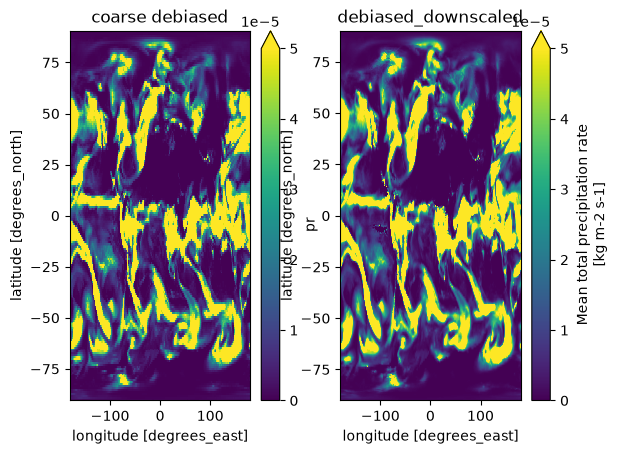

In [13]:
%%time
vmax = 5e-5
plt.subplot(1, 2, 1)
coarse_debiased.isel(time=0).plot(vmax=vmax)
plt.gca().set_title("coarse debiased")

plt.subplot(1, 2, 2)
debiased_downscaled.isel(time=0).plot(vmax=vmax)
plt.gca().set_title("debiased_downscaled")
# plt.tight_layout()

# Do evaluation

In [14]:
# DOY downscaled
# debiased_downscaled_doy = debiased_downscaled.groupby("time.dayofyear").mean()##.persist()

In [15]:
# DOY coarse
coarse_debiased_doy = coarse_debiased.groupby("time.dayofyear").mean()  ##.persist()

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


In [16]:
obs_fine_doy = obs_fine.groupby("time.dayofyear").mean()  # compute()
obs_coarse_doy = obs_coarse.groupby("time.dayofyear").mean()  ##.persist()

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


In [17]:
mean_obs = obs_fine.mean(dim="time")  # .compute()
mean_downscaled = debiased_downscaled.mean(dim="time")  # .compute()

In [18]:
mean_obs_coarse = obs_coarse.mean(dim="time")  # .persist()
mean_coarse_debiased = coarse_debiased.mean(dim="time")  # .persist()

In [19]:
pbias_fine = (mean_downscaled - mean_obs) / mean_obs * 100  # .persist()
mae_fine = mean_downscaled - mean_obs  # .persist()

In [20]:
pbias_coarse = (mean_coarse_debiased - mean_obs_coarse) / mean_obs_coarse * 100  # .persist()
mae_coarse = mean_coarse_debiased - mean_obs_coarse  # .persist()

# Evaluate bias in coarse

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


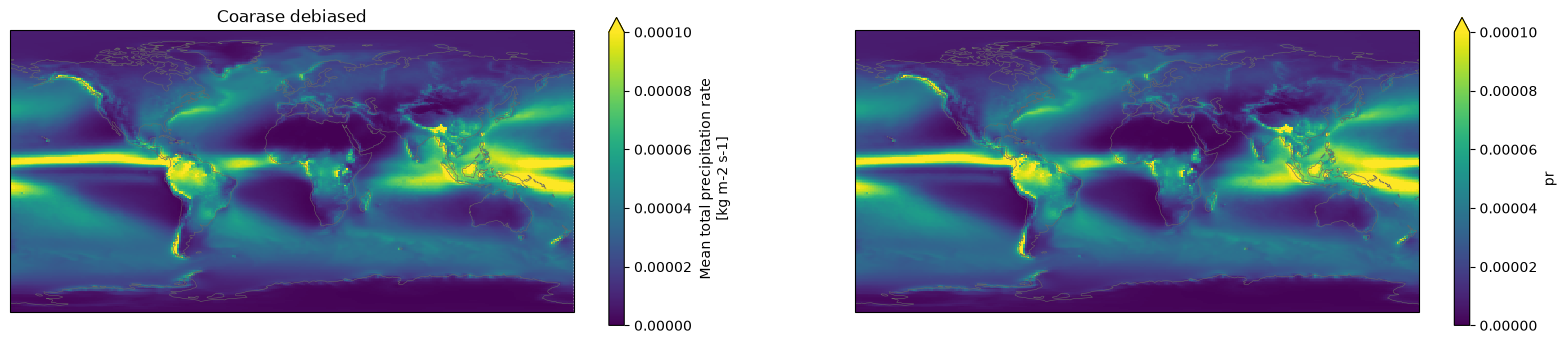

In [21]:
fig, axarr = plt.subplots(1, 2, figsize=(20, 4), subplot_kw={"projection": ccrs.PlateCarree()})

mean_obs_coarse.plot(ax=axarr[0], cmap="viridis", vmin=0, vmax=1e-4, transform=ccrs.PlateCarree())
axarr[0].set_title("Coarse obs")
mean_coarse_debiased.plot(
    ax=axarr[1], cmap="viridis", vmin=0, vmax=1e-4, transform=ccrs.PlateCarree()
)
axarr[0].set_title("Coarase debiased")
for ax in axarr:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")

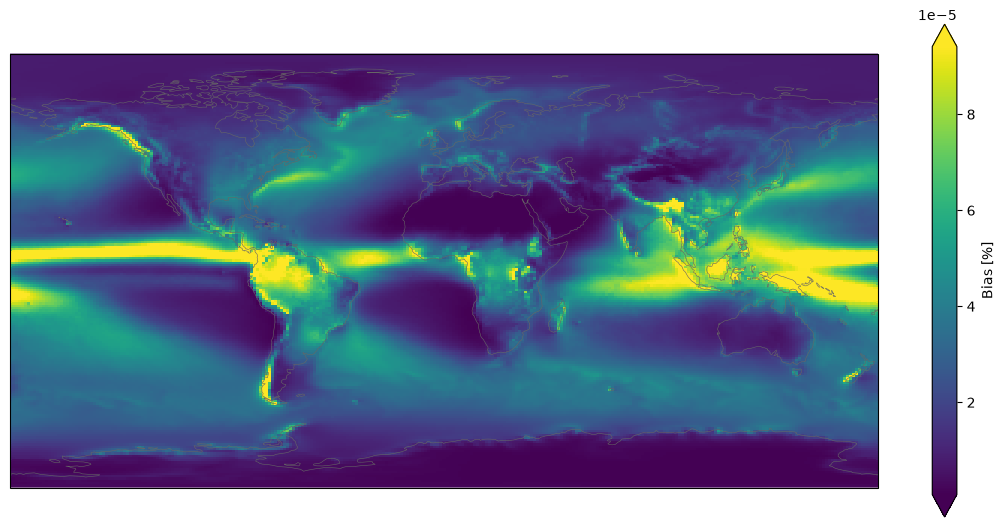

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mean_obs_coarse.plot(
    ax=ax,
    cmap="viridis",
    robust=True,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Bias [%]", "shrink": 0.8},
)

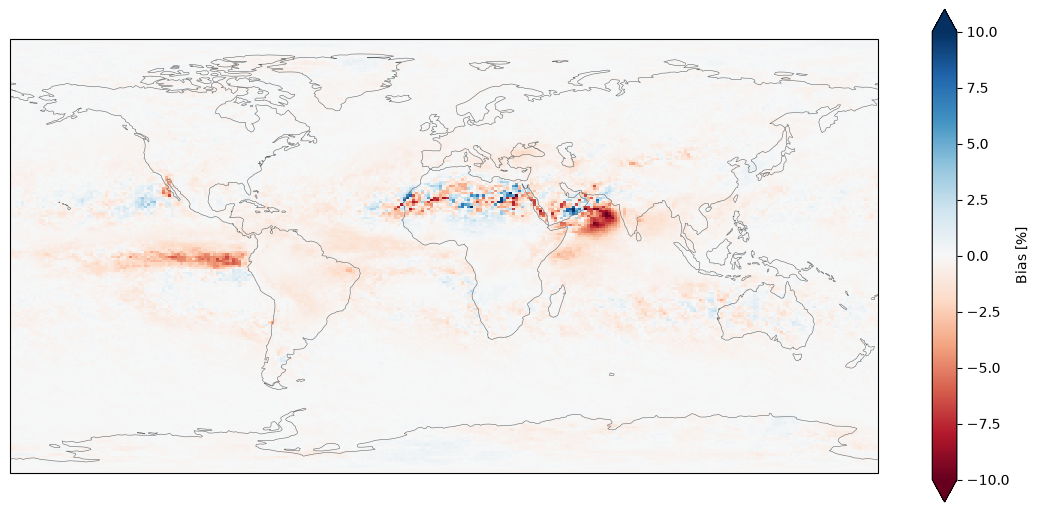

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
pbias_coarse.plot(
    ax=ax,
    vmin=-10,
    vmax=10,
    cmap="RdBu",
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Bias [%]", "shrink": 0.8},
)

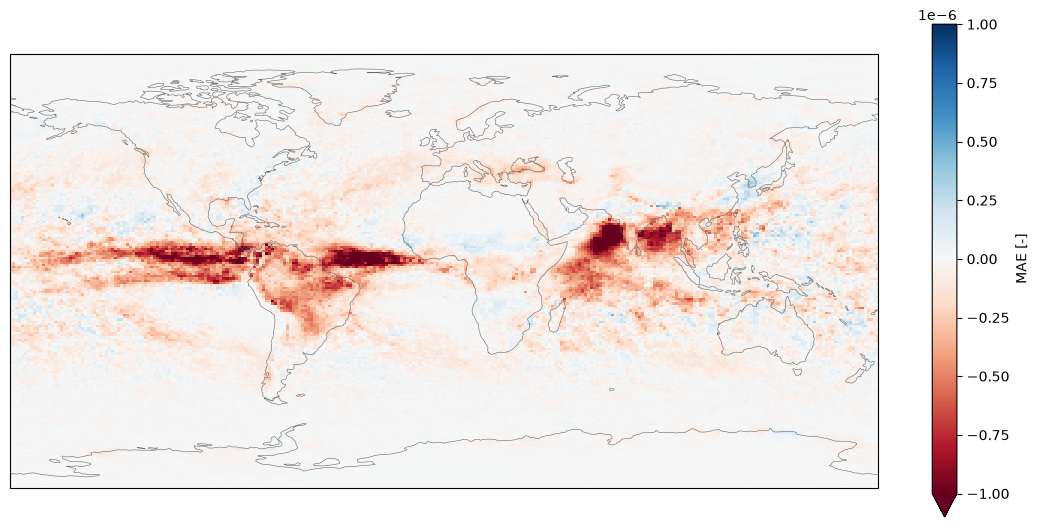

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mae_coarse.plot(
    vmin=-0.000001,
    vmax=0.000001,
    cmap="RdBu",
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "MAE [-]", "shrink": 0.8},
)

In [25]:
# Hot spots of both high MAE and high %bias
hot_spot_high = (pbias_coarse > 5) & (mae_coarse > 1e-7)

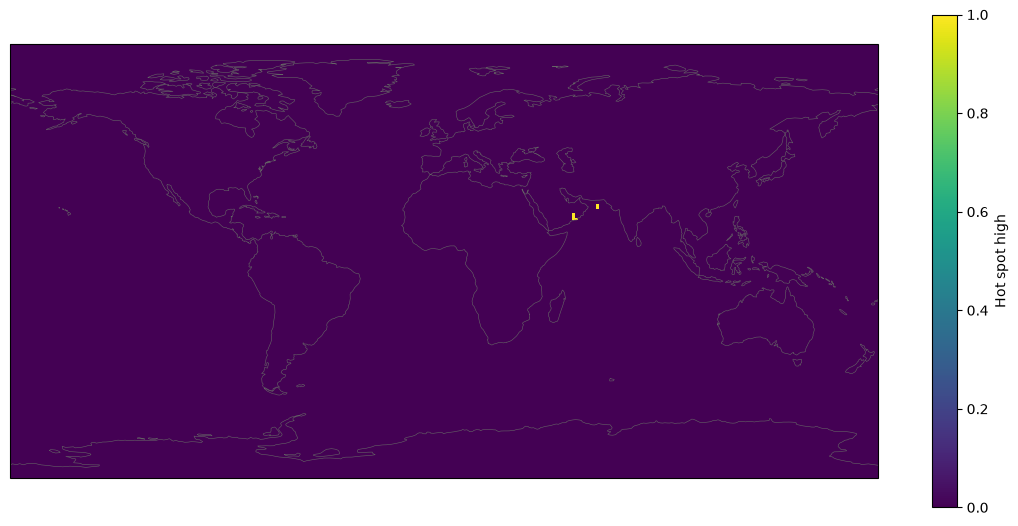

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_high.plot(
    transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8}
)

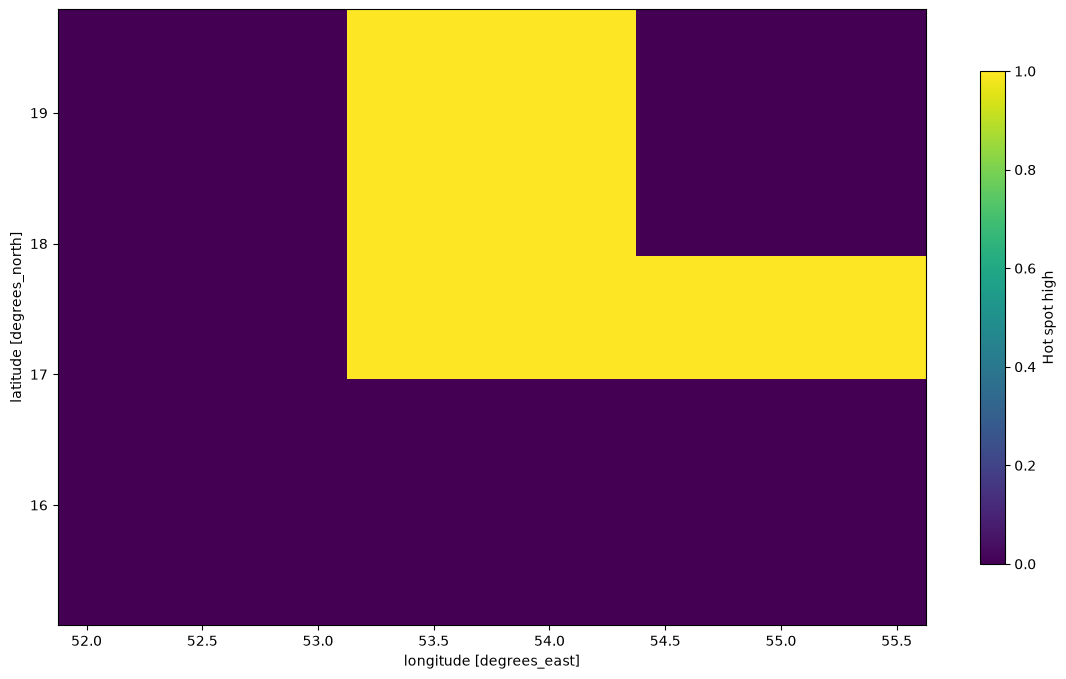

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
hot_spot_high.sel(lat=slice(15, 20), lon=slice(52, 56)).plot(
    cbar_kwargs={"label": "Hot spot high", "shrink": 0.8}
)

In [28]:
# Hot spots of both low MAE and low %bias
hot_spot_low = (pbias_coarse < -8) & (mae_coarse < -1e-6)

(array([-200., -150., -100.,  -50.,    0.,   50.,  100.,  150.,  200.]),
 [Text(-200.0, 0, '−200'),
  Text(-150.0, 0, '−150'),
  Text(-100.0, 0, '−100'),
  Text(-50.0, 0, '−50'),
  Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200')])

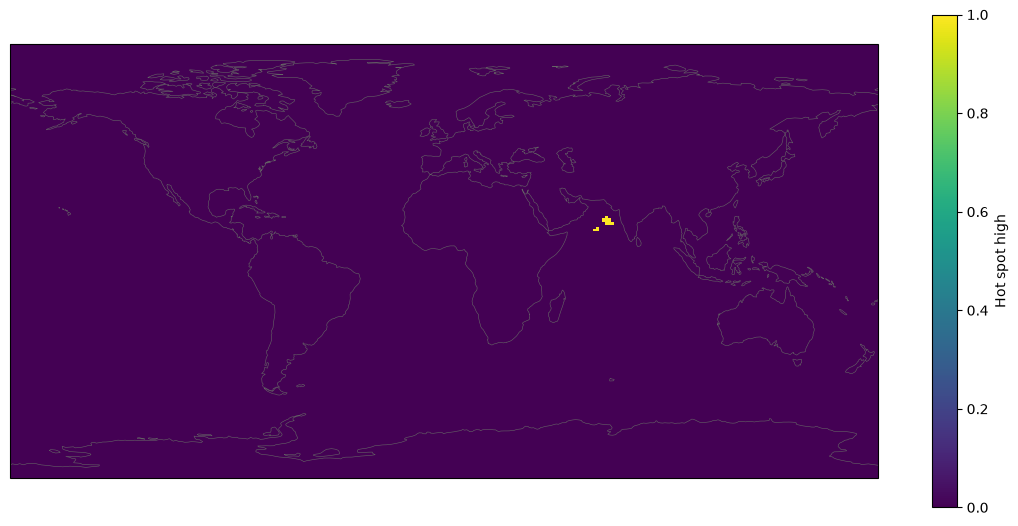

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_low.plot(
    transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8}
)
plt.xticks()

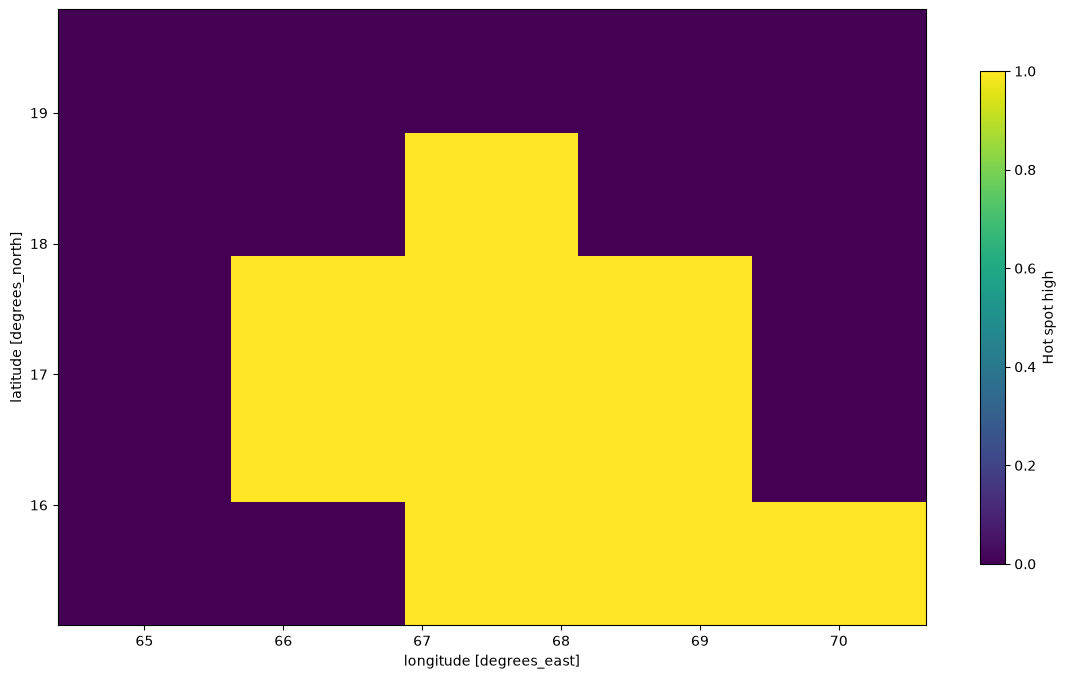

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
hot_spot_low.sel(lat=slice(15, 20), lon=slice(65, 70)).plot(
    cbar_kwargs={"label": "Hot spot high", "shrink": 0.8}
)

In [31]:
# grab pixel ho
hot_spot_coords = {"high": (17, 54), "low": (17, 68)}

# Evaluate bias in fine

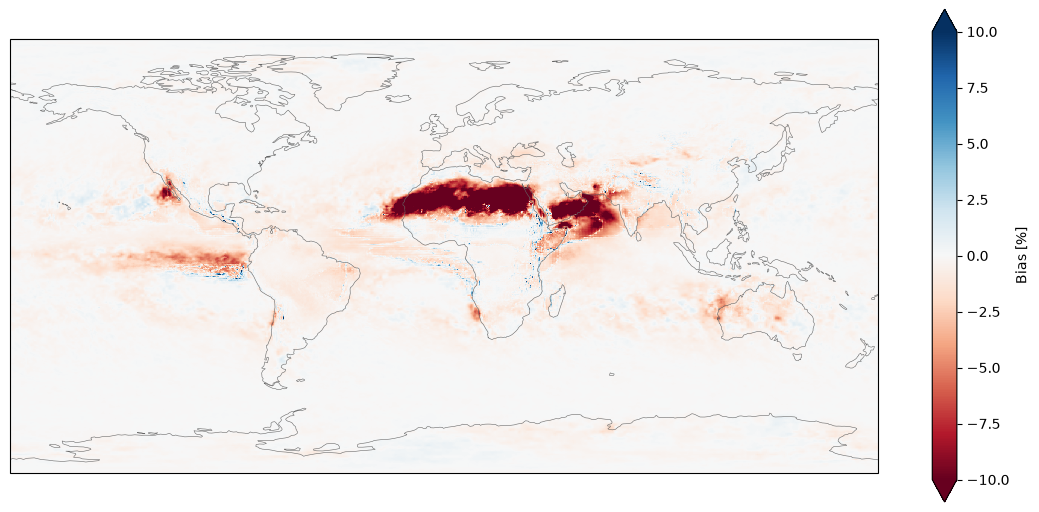

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
pbias_fine.plot(
    ax=ax,
    vmin=-10,
    vmax=10,
    cmap="RdBu",
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Bias [%]", "shrink": 0.8},
)

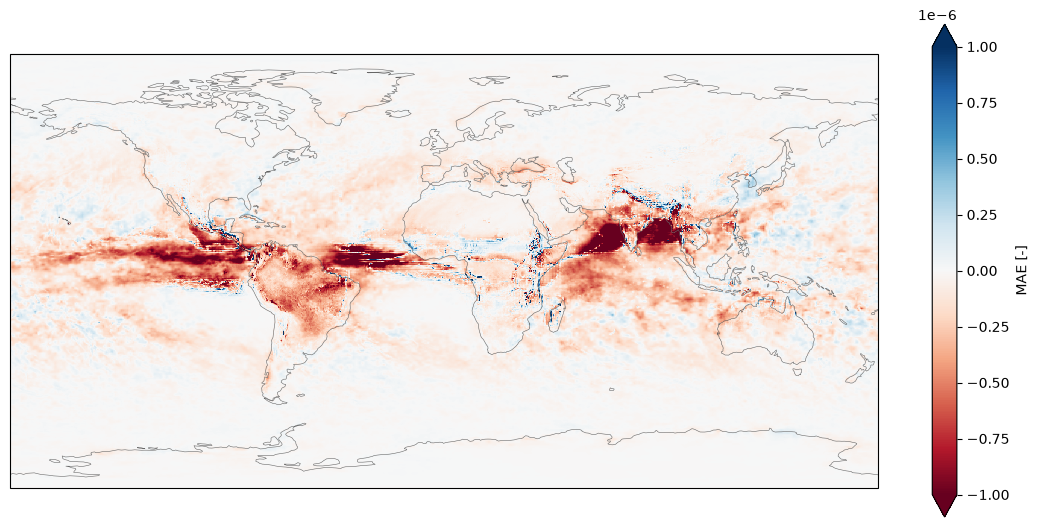

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mae_fine.plot(
    vmin=-0.000001,
    vmax=0.000001,
    cmap="RdBu",
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "MAE [-]", "shrink": 0.8},
)

In [34]:
# Hot spots of both low MAE and low %bias
hot_spot_low = (pbias_fine < -8) & (mae_fine < -1e-6)
hot_spot_high = (pbias_fine > 5) & (mae_fine > 1e-7)

(array([-200., -150., -100.,  -50.,    0.,   50.,  100.,  150.,  200.]),
 [Text(-200.0, 0, '−200'),
  Text(-150.0, 0, '−150'),
  Text(-100.0, 0, '−100'),
  Text(-50.0, 0, '−50'),
  Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200')])

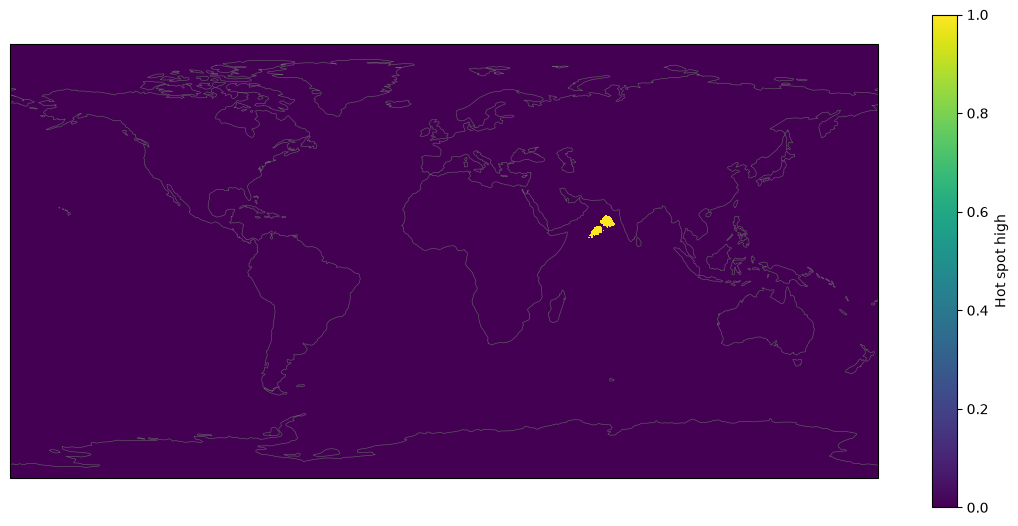

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_low.plot(
    transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8}
)
plt.xticks()

(array([-200., -150., -100.,  -50.,    0.,   50.,  100.,  150.,  200.]),
 [Text(-200.0, 0, '−200'),
  Text(-150.0, 0, '−150'),
  Text(-100.0, 0, '−100'),
  Text(-50.0, 0, '−50'),
  Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200')])

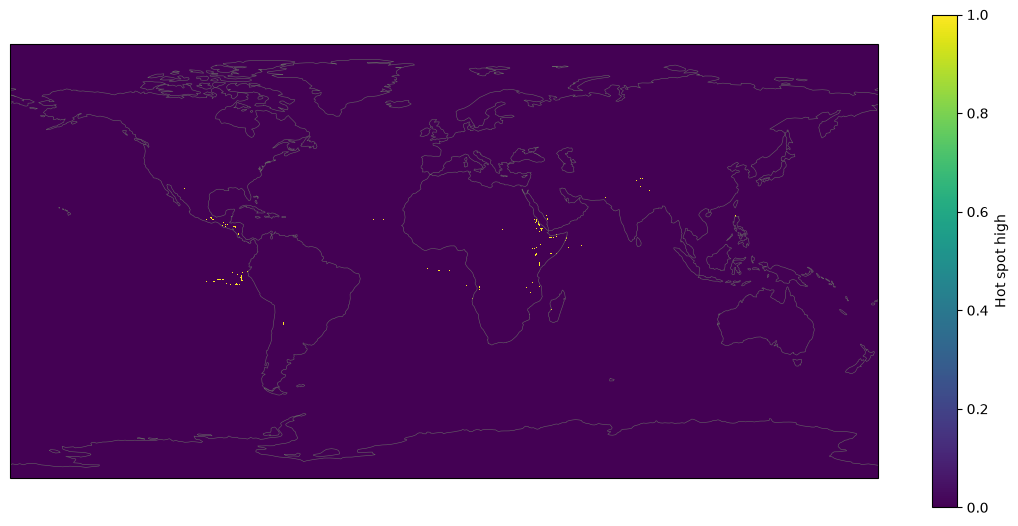

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_high.plot(
    transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8}
)
plt.xticks()

# CDF comparison across locations


In [37]:
locations["High hot spot Oman"] = (17, 54)
locations["Low hot spot Arabian Sea"] = (17, 68)

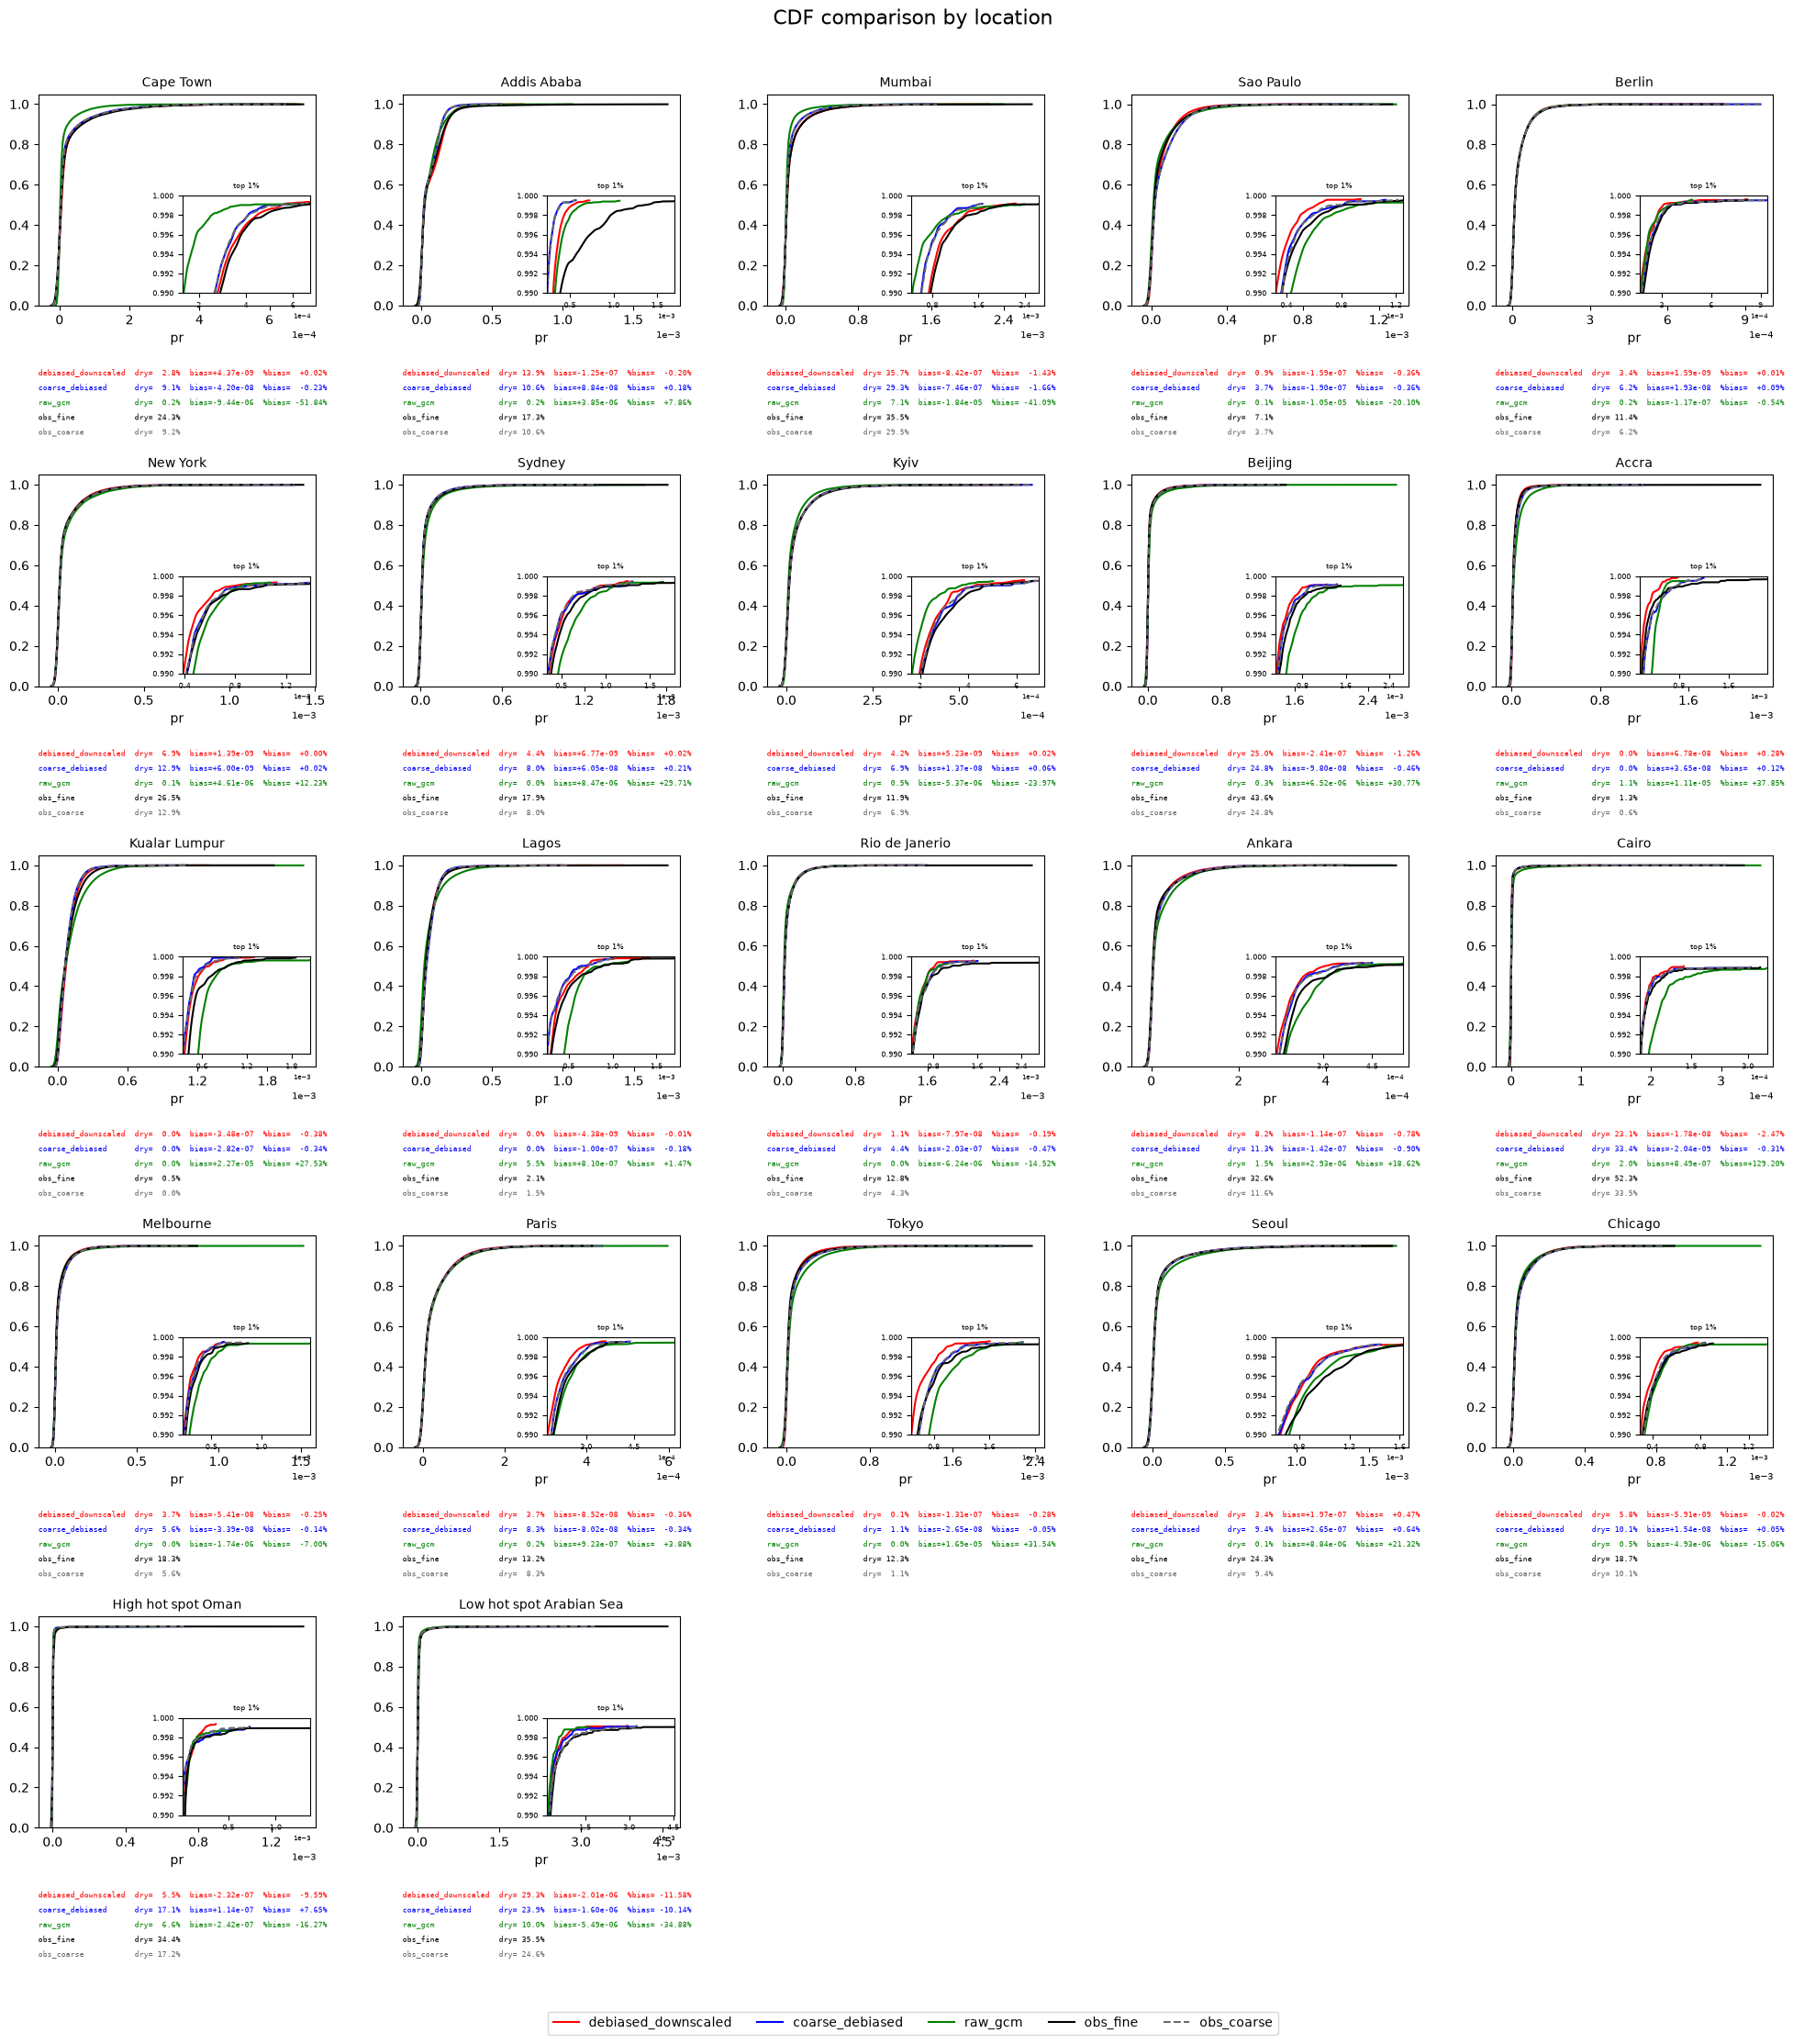

In [38]:
fig = plot_cdf_by_location(
    debiased_downscaled=debiased_downscaled,
    coarse_debiased=coarse_debiased,
    obs_fine=obs_fine,
    obs_coarse=obs_coarse,
    raw_gcm=raw,
    locations=locations,
    var=var,
)

# High bias hot spot Oman

In [39]:
(lat, lon) = locations["High hot spot Oman"]

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


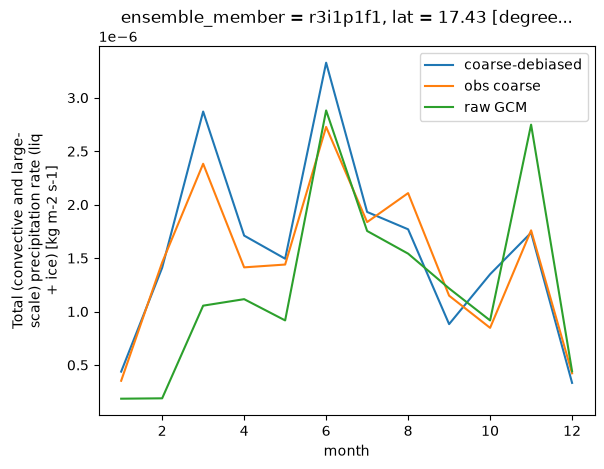

In [40]:
coarse_debiased.sel(lat=lat, lon=lon, method="nearest").groupby("time.month").mean().plot(
    label="coarse-debiased"
)
obs_coarse.sel(lat=lat, lon=lon, method="nearest").groupby("time.month").mean().plot(
    label="obs coarse"
)
raw.sel(lat=lat, lon=lon, method="nearest").groupby("time.month").mean().plot(label="raw GCM")
plt.legend()

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


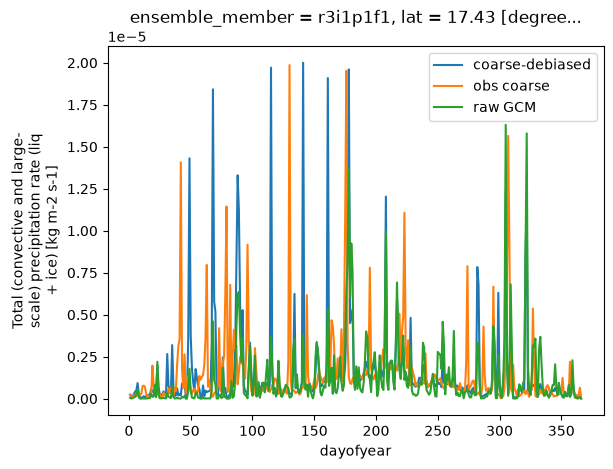

In [41]:
coarse_debiased.sel(lat=lat, lon=lon, method="nearest").groupby("time.dayofyear").mean().plot(
    label="coarse-debiased"
)
obs_coarse.sel(lat=lat, lon=lon, method="nearest").groupby("time.dayofyear").mean().plot(
    label="obs coarse"
)
raw.sel(lat=lat, lon=lon, method="nearest").groupby("time.dayofyear").mean().plot(label="raw GCM")

plt.legend()

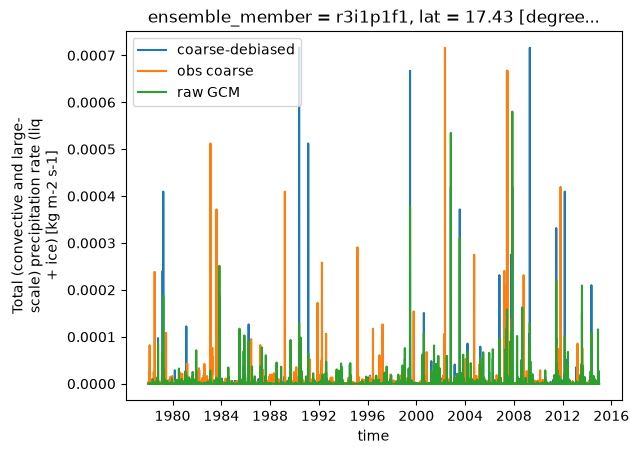

In [42]:
coarse_debiased.sel(lat=lat, lon=lon, method="nearest").plot(label="coarse-debiased")

obs_coarse.sel(lat=lat, lon=lon, method="nearest").plot(label="obs coarse")
raw.sel(lat=lat, lon=lon, method="nearest").plot(label="raw GCM")

plt.legend()

In [43]:
(
    coarse_debiased.sel(lat=lat, lon=lon, method="nearest").mean()
    / obs_coarse.sel(lat=lat, lon=lon, method="nearest").mean()
).values

array(1.0765394, dtype=float32)

In [44]:
# Low bias hot spot Arabian Sea

In [45]:
# I think this is a result of the maximum factor that we're allowed to

In [46]:
(lat, lon) = locations["Low hot spot Arabian Sea"]

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


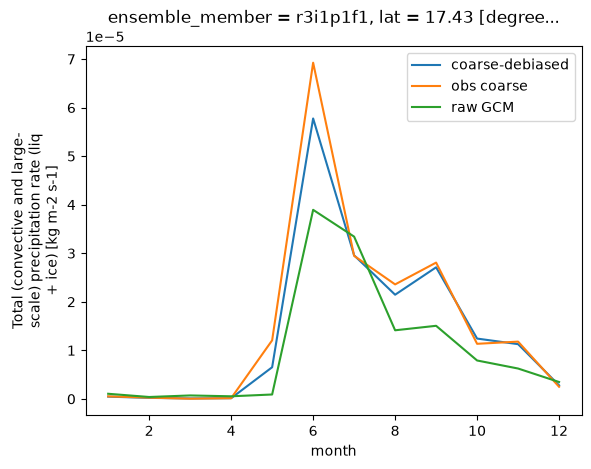

In [47]:
coarse_debiased.sel(lat=lat, lon=lon, method="nearest").groupby("time.month").mean().plot(
    label="coarse-debiased"
)
obs_coarse.sel(lat=lat, lon=lon, method="nearest").groupby("time.month").mean().plot(
    label="obs coarse"
)
raw.sel(lat=lat, lon=lon, method="nearest").groupby("time.month").mean().plot(label="raw GCM")
plt.legend()

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


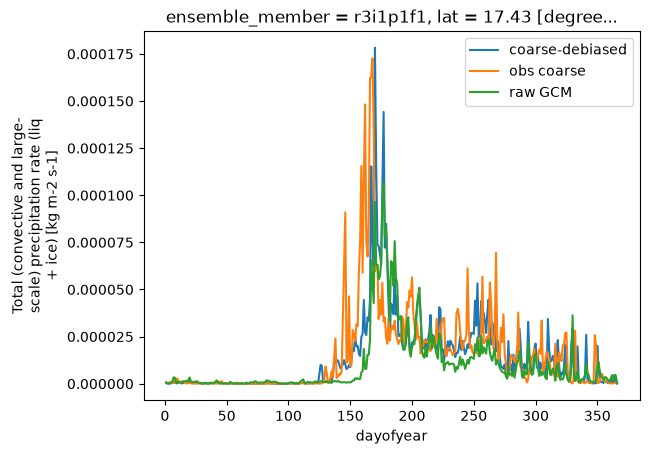

In [48]:
coarse_debiased.sel(lat=lat, lon=lon, method="nearest").groupby("time.dayofyear").mean().plot(
    label="coarse-debiased"
)
obs_coarse.sel(lat=lat, lon=lon, method="nearest").groupby("time.dayofyear").mean().plot(
    label="obs coarse"
)
raw.sel(lat=lat, lon=lon, method="nearest").groupby("time.dayofyear").mean().plot(label="raw GCM")

plt.legend()

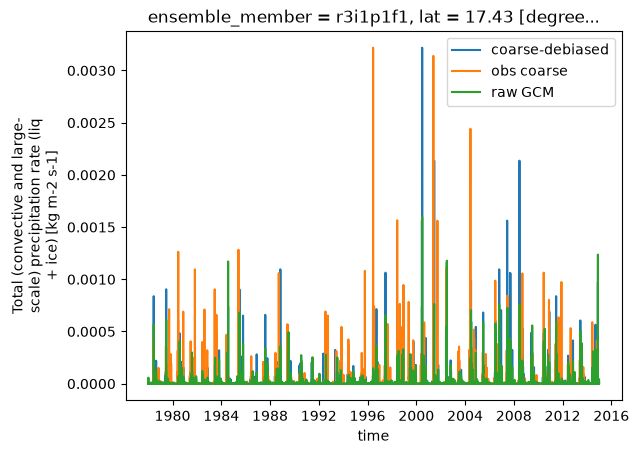

In [49]:
coarse_debiased.sel(lat=lat, lon=lon, method="nearest").plot(label="coarse-debiased")

obs_coarse.sel(lat=lat, lon=lon, method="nearest").plot(label="obs coarse")
raw.sel(lat=lat, lon=lon, method="nearest").plot(label="raw GCM")

plt.legend()